# ETF NAV premium/discount — a quantitative teardown 🔬
### NAV-proxy basis construction · hedged-harvest with a HAC *t* + placebo null · the per-ETF sign reversal · a cost / threshold / stress battery · a faithful-engine control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Free_discount%3F: Busted](https://img.shields.io/badge/Free_discount%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim *"buy below NAV, earn the discount back"* fuses two things we separate: a **basis that mean-reverts** (true, by stationarity) and a **harvestable, net-of-cost return** (the only thing that pays). We measure the *hedged* residual — the ETF's move minus its fair-value basket — so the number is the **gap closing**, not the bond market rallying. The decisive object is its **magnitude vs the round-trip**, not its sign.

> ⚠️ **Data + proxy note.** Official intraday iNAV / end-of-day NAV isn't on yfinance; we build a transparent **NAV proxy** — a per-ETF hedge-basket fair value (sister credit ETF + rate leg), with the **basis** = detrended cumulative return residual (stationary, like a real prem/disc). A tighter true NAV only *shrinks* the gap. Real data: yfinance daily adjusted closes, HYG/EMB/MUB + legs, 2012→2026. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from etf_nav_premium import data, strategy as st

HAVE_REAL = data.have_real()
FRAMES = data.load_real() if HAVE_REAL else None
print("real ETF-price cache present:", HAVE_REAL,
      "| target ETFs:", (list(FRAMES) if FRAMES else None))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2012-01-03', 'end': '2026-06-18', 'days': 3636, 'years': 14.5, 'targets': ['HYG', 'EMB', 'MUB'], 'pool': [(5, 1664, 0.0525, 56, 2.03), (10, 1663, 0.0496, 54, 1.24), (20, 1663, 0.0543, 53, 0.92)], 'per': {'HYG': (504, -0.27, -0.0119, 45, -0.58, 0.978), 'EMB': (597, -1.47, 0.0696, 54, 0.67, 0.028), 'MUB': (562, -0.36, 0.0835, 64, 2.4, 0.0)}, 'costs': [(1.0, 0.04, 0.0125), (2.0, 0.08, -0.0275), (3.0, 0.12, -0.0675)], 'robust': [(-0.5, 3047, 0.0441, 56, 2.83), (-1.0, 1664, 0.0525, 56, 2.03), (-1.5, 846, 0.0654, 56, 1.53), (-2.0, 403, 0.1338, 58, 1.74)], 'stress': {'HYG': (24, -1.04, '2016-05-09'), 'EMB': (22, -9.31, '2020-03-18'), 'MUB': (25, -4.43, '2020-03-18')}, 'syn': [(0.0, 576, -0.0642, -1.17, 0.989), (5.0, 576, 0.1702, 3.1, 0.001)]}


real ETF-price cache present: True | target ETFs: ['HYG', 'EMB', 'MUB']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | pooled hedged harvest **+0.0525%** / 5-day, HAC **t = 2.03** — but **t = 1.24** by 10 days, and **HYG t = -0.58** (sign reversal across ETFs). |
| **Tradability** | `MIRAGE` | gross ~5 bp < round-trip: net **-0.0275%** at 2 bp/leg. Deepest discounts ~25% in 2020 (uniform ~7%) — un-harvestable in stress. |
| **Free discount?** | `BUSTED` | the *t* **fades as the discount deepens** (1.53 at z<−1.5) and is carried by one ETF (MUB). A fair-value wobble, not a structural arb. |

> 💡 In plain words: the basis reverts because it's *built* to be stationary; the question is whether the buyer keeps anything. Strip the beta and charge the spread and ~5 bp becomes ≤ 0 — and the giant discounts are the ones you can't touch.

## 1 · The claim, steelmanned

Let $p_t = \log P^{\text{ETF}}_t$ and let $\hat\nu_t$ be a NAV-proxy fair value (a hedge basket of a sister ETF + a rate leg). Define the **basis** $b_t = (p_t - \hat\nu_t)$ detrended by a rolling mean — stationary, so $\mathbb{E}[\Delta b \mid b<0] > 0$ *by construction*. A **discount** fires when the rolling z-score $z_t = (b_t-\bar b)/s_b < -1$.

- **H₁ (the discount is harvestable).** The **hedged** residual return after a discount, $\sum_{i=1}^{h} \varepsilon_{t+i}$, is positive with $t \ge 2$ — a *net-of-beta* edge.
- **H₂ (it's deployable).** That harvest exceeds the round-trip half-spread on the ETF **and** the hedge leg, at scale, including in stress.
- **H₃ ("free discount").** The harvest is a structural property of below-NAV, stable across ETFs and *stronger* in deep discounts.

We find **H₁ marginal** (pooled t≈2 at 5d, <2 beyond, sign-flips on HYG), **H₂ rejected** (gross < cost; stress-clustered), **H₃ rejected** (t *fades* with depth; one-ETF effect). The basis reverts; the investor doesn't get paid for it.

## 2 · So what? — what rides on each answer

The whole teardown is one estimator: the mean **hedged** harvest after a discount, judged by a HAC standard error (overlapping holds ⇒ autocorrelation).

$$\widehat{H}_h = \frac{1}{k}\sum_{j=1}^{k}\sum_{i=1}^{h}\varepsilon_{\tau_j+i},\qquad t = \frac{\widehat{H}_h}{\widehat{\mathrm{se}}_{\text{NW}}(\widehat{H}_h)}.$$

Three traps a naive test falls into: (1) using the **raw** ETF return — that's mostly the bond market, so we hedge to the residual $\varepsilon$; (2) using a **plain** t on overlapping holds — autocorrelation inflates it, so we use Newey-West; (3) reading a stationary basis's reversion as *profit* — it's not, unless it clears the **round-trip**. The cost line, not the point estimate, is where the verdict is decided.

## 3 · How we'd know — the protocol

- **NAV proxy.** Per ETF, OLS-hedge daily log-returns on the legs (sister ETF + rates); residual $\varepsilon_t$ = ETF − hedge; basis $b_t$ = detrended cumulative $\varepsilon$ (rolling-60d). Explicit **proxy** for official NAV. 2012-01-03→2026-06-18, 3,636 days.
- **Discount detector.** Rolling-252d z of $b_t$; fire when $z<-1$ (sweep $-0.5…-2$).
- **Harvest.** $\sum_{i=1}^h \varepsilon_{t+i}$, entered **1 day after** the signal (no look-ahead), $h\in\{5,10,20\}$; events overrunning the tape dropped.
- **Inference.** Newey-West (Bartlett, 10-lag) HAC t; plus a **placebo** null — 20,000 draws of $k$ random valid entry dates, $p=\Pr[\text{random mean}\ge\text{discount mean}]$.
- **Costs.** One-way half-spread × (ETF + hedge) legs, swept 1–3 bp.
- **Stress check.** Share of each ETF's deepest-5% discounts falling in 2020.
- **Positive control.** AR(1) basis with a **planted per-day earn-back** on discount days: the inference must recover a large edge **and** must NOT manufacture one at zero edge.

## 4 · The teardown

### 4a · The point estimates — positive, tiny, decaying

Pooled hedged harvest by horizon with its $\pm$ HAC standard error, and the Newey-West *t* annotated. Positive everywhere, but the *t* only clears 2 at 5 days and decays after.

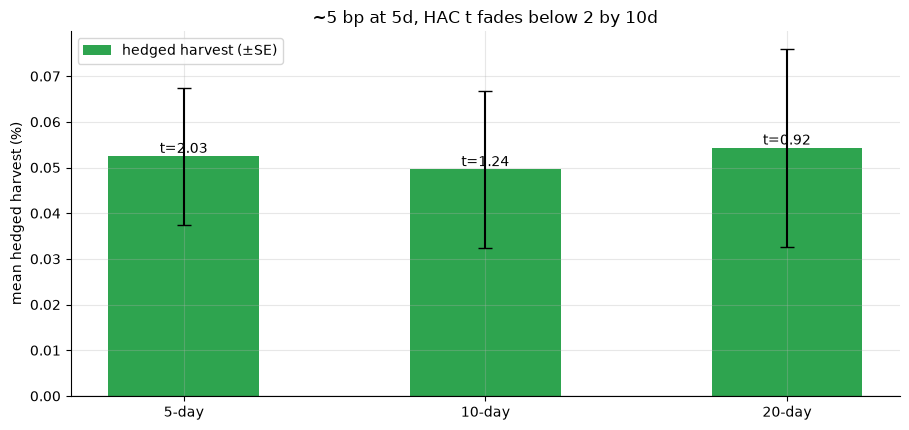

pooled harvest %: {'5d': np.float64(0.0525), '10d': np.float64(0.0496), '20d': np.float64(0.0543)} | HAC t: {'5d': 2.03, '10d': 1.24, '20d': 0.92}


In [2]:
hs = [h for h,*_ in R['pool']]
if HAVE_REAL:
    hv = []; ses = []; ts = []
    for h in hs:
        xs = []
        for f in FRAMES.values():
            ev = st.detect_discounts(f); xs.append(st.hedged_harvest(f, ev, h))
        x = np.concatenate(xs); hv.append(x.mean()*100)
        ses.append(x.std(ddof=1)/np.sqrt(len(x))*100); ts.append(st.hac_t(x))
else:
    hv = [p[2] for p in R['pool']]; ts = [p[4] for p in R['pool']]; ses=[0.026,0.04,0.059]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x, hv, yerr=ses, capsize=5, color=GREEN, width=.5, label='hedged harvest (±SE)')
ax.axhline(0, c='k', lw=.8)
for i,(v,t) in enumerate(zip(hv,ts)): ax.annotate(f't={t:.2f}',(i,v),ha='center',va='bottom')
ax.set_xticks(x); ax.set_xticklabels([f'{h}-day' for h in hs])
ax.set_ylabel('mean hedged harvest (%)')
ax.set_title('~5 bp at 5d, HAC t fades below 2 by 10d'); ax.legend()
plt.tight_layout(); plt.show()
print('pooled harvest %:', {f'{h}d': round(v,4) for h,v in zip(hs,hv)}, '| HAC t:', {f'{h}d': round(t,2) for h,t in zip(hs,ts)})

> 💡 In plain words: at 5 days the harvest is **+0.0525%** at **t = 2.03** (just clears 2); by 10 days **t = 1.24**, by 20 days **t = 0.92**. The mean barely moves but the standard error grows — a classic *not-an-edge* signature: a positive number that can't keep its significance.

### 4b · The decisive split — it reverses sign across ETFs

A structural "free discount" must exist in every ETF. Here's the hedged 10-day earn-back per fund with its HAC *t* — and one of them is **negative**.

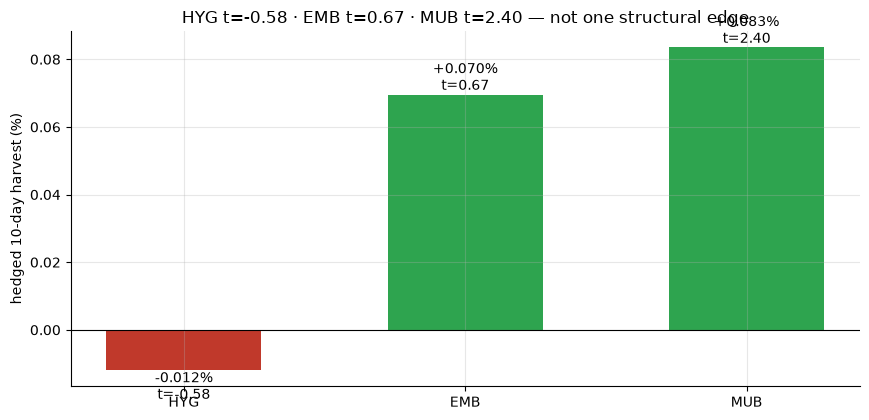

per-ETF (harvest%, t): {'HYG': (-0.0119, -0.58), 'EMB': (0.0696, 0.67), 'MUB': (0.0835, 2.4)}


In [3]:
names = R['targets']
if HAVE_REAL:
    vals = []; ts = []
    for tg in names:
        ev = st.detect_discounts(FRAMES[tg]); s = st.summarize(FRAMES[tg], ev, 10)
        vals.append(s['harvest_mean']*100); ts.append(s['t'])
else:
    vals = [R['per'][tg][2] for tg in names]; ts = [R['per'][tg][4] for tg in names]
fig, ax = plt.subplots(figsize=(8.8, 4.3))
cols = [GREEN if v>0 else RED for v in vals]
ax.bar(names, vals, color=cols, width=.55)
ax.axhline(0, c='k', lw=.8)
for i,(v,t) in enumerate(zip(vals,ts)): ax.annotate(f'{v:+.3f}%\nt={t:.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.set_ylabel('hedged 10-day harvest (%)')
ax.set_title('HYG t=-0.58 · EMB t=0.67 · MUB t=2.40 — not one structural edge')
plt.tight_layout(); plt.show()
print('per-ETF (harvest%, t):', {tg:(round(v,4),round(t,2)) for tg,v,t in zip(names,vals,ts)})

> 💡 In plain words: **HYG t = -0.58** (buying HY's discount *loses*, hedged), **EMB t = 0.67** (noise), **MUB t = 2.40** (the only one with a pulse). The pooled t≈2 is **one ETF wearing a crowd**. A law of ETF microstructure wouldn't pick favourites — H₃ rejected.

### 4c · Costs + the depth paradox — neither rescues it

Left: the pooled 5-day harvest vs the round-trip half-spread (ETF + hedge). Right: the HAC *t* as we tighten the discount threshold — it should *strengthen* in the deep tail if the effect were structural; it **fades**.

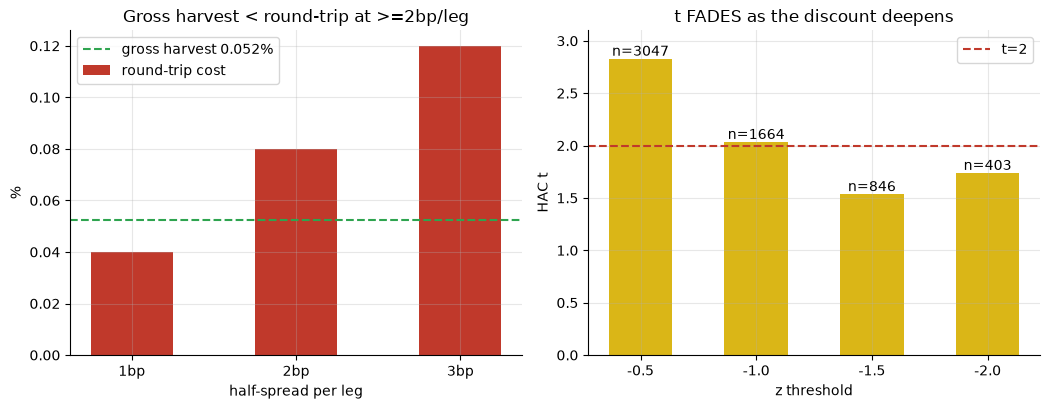

robustness (z, n, t): [(-0.5, 3047, 2.83), (-1.0, 1664, 2.03), (-1.5, 846, 1.53), (-2.0, 403, 1.74)]


In [4]:
if HAVE_REAL:
    g5 = st.pooled_harvest(FRAMES, 5)['harvest_mean']*100
    rob = []
    for zt in (-0.5,-1.0,-1.5,-2.0):
        p = st.pooled_harvest(FRAMES, 5, z_thr=zt); rob.append((zt, p['n'], p['t']))
else:
    g5 = R['pool'][0][2]; rob = [(r[0], r[1], r[4]) for r in R['robust']]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.2))
cbs = [c[0] for c in R['costs']]; costv = [c[1] for c in R['costs']]
a1.bar([f'{c:.0f}bp' for c in cbs], costv, color=RED, width=.5, label='round-trip cost')
a1.axhline(g5, ls='--', c=GREEN, label=f'gross harvest {g5:.3f}%')
a1.set_title('Gross harvest < round-trip at >=2bp/leg'); a1.set_xlabel('half-spread per leg'); a1.set_ylabel('%'); a1.legend()
zs = [r[0] for r in rob]; tt = [r[2] for r in rob]; ns = [r[1] for r in rob]
a2.bar([f'{z:.1f}' for z in zs], tt, color=AMBER, width=.55)
a2.axhline(2, ls='--', c=RED, label='t=2')
for i,(t,k) in enumerate(zip(tt,ns)): a2.annotate(f'n={k}',(i,t),ha='center',va='bottom')
a2.set_title('t FADES as the discount deepens'); a2.set_xlabel('z threshold'); a2.set_ylabel('HAC t'); a2.set_ylim(0,3.1); a2.legend()
plt.tight_layout(); plt.show()
print('robustness (z, n, t):', [(r[0], r[1], round(r[2],2)) for r in rob])

> 💡 In plain words: a 2-bp/leg round-trip (**0.08%**) already exceeds the 5-bp gross. And the *t* is **largest at the loosest threshold** (z<−0.5, where 'discount' means almost anything) and **smallest in the deep tail** (1.53 at z<−1.5) — the exact opposite of a real dislocation edge, which should bite hardest when the gap is biggest. This is broad, shallow mean-reversion, not discount-harvesting.

### 4d · The stress trap & the faithful-engine control

Left: where the deepest discounts live (calendar). Right: the positive control — an AR(1) basis with a planted per-day earn-back: zero edge must stay below t=2, a large edge must light up.

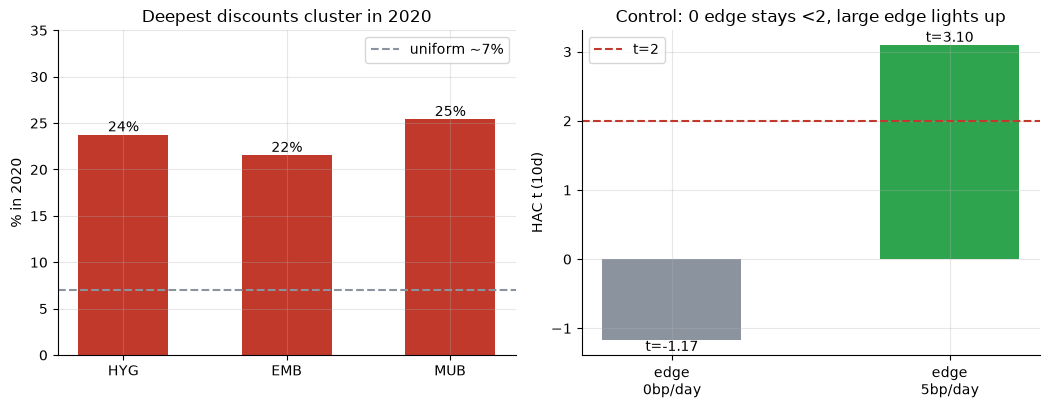

planted 0bp/day: detected=576 harvest=-0.0642% t=-1.17 p=0.989
planted 5bp/day: detected=576 harvest=+0.1702% t=3.10 p=0.001


In [5]:
names = R['targets']
if HAVE_REAL:
    shares = []
    for tg in names:
        b = FRAMES[tg]['basis']; deep = b[b < b.quantile(0.05)]
        shares.append((deep.index.year==2020).mean()*100)
else:
    shares = [R['stress'][tg][0] for tg in names]
res = []
for edge in (0.0, 5.0):
    syn = data.synthetic_basis(edge_bps=edge, seed=378)
    ev = st.detect_discounts(syn); s = st.summarize(syn, ev, 10)
    res.append((edge, s['n'], s['harvest_mean']*100, s['t'], s['p_placebo']))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.2))
a1.bar(names, shares, color=RED, width=.55); a1.axhline(7, ls='--', c=GREY, label='uniform ~7%')
for i,v in enumerate(shares): a1.annotate(f'{v:.0f}%',(i,v),ha='center',va='bottom')
a1.set_title('Deepest discounts cluster in 2020'); a1.set_ylabel('% in 2020'); a1.set_ylim(0,35); a1.legend()
labels = [f'edge\n{e:.0f}bp/day' for e,*_ in res]; tv = [r[3] for r in res]
a2.bar(labels, tv, color=[GREY, GREEN], width=.5); a2.axhline(2, ls='--', c=RED, label='t=2')
for i,t in enumerate(tv): a2.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom' if t>=0 else 'top')
a2.set_title('Control: 0 edge stays <2, large edge lights up'); a2.set_ylabel('HAC t (10d)'); a2.legend()
plt.tight_layout(); plt.show()
for e,k,c,t,p in res: print(f'planted {e:.0f}bp/day: detected={k} harvest={c:+.4f}% t={t:.2f} p={p:.3f}')

> 💡 In plain words: ~25% of the worst discounts hit in 2020 — when the creation/redemption arb froze and the underlying bonds stopped trading, so the 'discount' was partly **stale NAV**, not a bargain you could lift. And the control is clean: zero planted edge → **t = -1.17** (no false positive), a 5 bp/day edge → **t = 3.10**, p = 0.001. The engine is honest — so the real tape's marginal, cost-dominated, stress-clustered t is exactly what *no harvestable edge* looks like.

## 5 · The verdict

- **Signal `WEAK`** — pooled hedged harvest **+0.0525%/5d** at HAC **t = 2.03**, but **t = 1.24** by 10d, **HYG t = -0.58** (sign flip), and the *t* **fades with depth**. A stationary basis's reversion + a marginal, non-robust point estimate ⇒ WEAK, not REAL (and the NAV is a **proxy**).
- **Tradability `MIRAGE`** — gross ~5 bp is **below** a 2-bp/leg round-trip (net **-0.0275%**); deepest discounts ~25% in 2020, un-harvestable when the arb breaks. No deployable edge.
- **Free discount? `BUSTED`** — below-NAV isn't 'on sale': most of the gap is the basket, what reverts is pennies, costs erase it, the effect is one-ETF and *weakens* in the deep tail, and the giant gaps are stale-NAV stress artefacts you can't trade.

## 6 · Could you trade it? — the break-even spread

The operational truth in one picture: how tight would your **all-in round-trip** have to be for the discount harvest to clear zero? Below the break-even you'd need a spread tighter than these bond ETFs offer even in calm markets — and far tighter than they offer in the stress where the big discounts live.

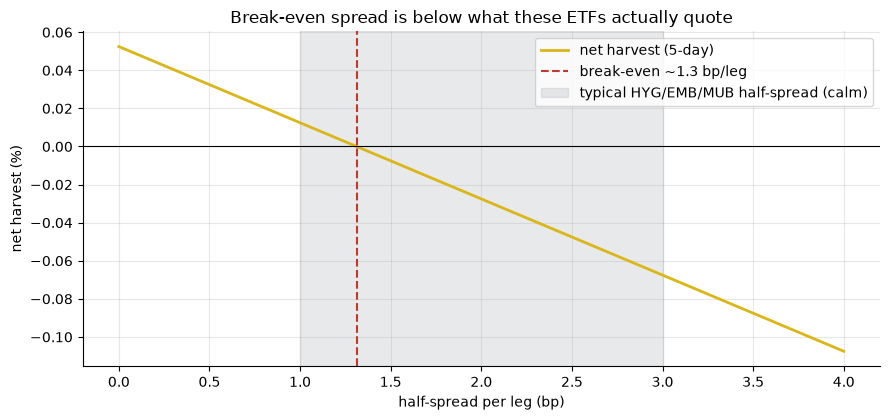

gross 5d harvest 0.0525% -> break-even half-spread ~1.3 bp/leg (typical calm spread already 1-3 bp; stress 10-30 bp+)


In [6]:
if HAVE_REAL:
    g5 = st.pooled_harvest(FRAMES, 5)['harvest_mean']*100
else:
    g5 = R['pool'][0][2]
legs = 2
spreads = np.linspace(0, 4, 100)            # half-spread per leg, bp
net = g5 - 2*legs*spreads/100              # round-trip on both legs, %
breakeven = g5/(2*legs)*100                # half-spread/leg that zeroes it, bp
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(spreads, net, c=AMBER, lw=2, label='net harvest (5-day)')
ax.axhline(0, c='k', lw=.8)
ax.axvline(breakeven, c=RED, ls='--', label=f'break-even ~{breakeven:.1f} bp/leg')
ax.axvspan(1, 3, color=GREY, alpha=.2, label='typical HYG/EMB/MUB half-spread (calm)')
ax.set_xlabel('half-spread per leg (bp)'); ax.set_ylabel('net harvest (%)')
ax.set_title('Break-even spread is below what these ETFs actually quote'); ax.legend()
plt.tight_layout(); plt.show()
print(f'gross 5d harvest {g5:.4f}% -> break-even half-spread ~{breakeven:.1f} bp/leg (typical calm spread already 1-3 bp; stress 10-30 bp+)')

> 💡 In plain words: the break-even half-spread is on the order of a **single basis point per leg** — and HYG/EMB/MUB routinely quote *wider* than that even on quiet days, blowing out to tens of bps in the exact stress where the discounts get large. There is no spread regime in which this clears: the harvest **is** the spread. Even granting the reversion is real, the wrapper's own friction eats 100% of it — **the discount is a feature of the microstructure, not a payout from it.**

## 7 · Going further

- **Real NAV, faster arb.** Replace the hedge-basket proxy with issuer daily NAV (or intraday iNAV from a paid feed); the basis tightens and the harvest shrinks — the true creation/redemption arbitrage is faster than our proxy, so our number is an *upper* bound.
- **Stale-NAV decomposition.** Regress next-day NAV change on today's discount to quantify how much of the 'gap' is the NAV catching down to a price the ETF already discovered (Madhavan-Sobczyk; Pan-Zeng).
- **Equity vs credit.** Re-run on SPY/IVV (arb tight, nothing to harvest) vs HY/EM/munis (arb loose, costs high) — the 'discount edge' lives only where it can't be banked.

*The reproducible core is offline and deterministic; the NAV input is an explicit proxy. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*